# Team 8 — Delhi Air Quality: Preprocessing, DB Benchmark & Forecast

Three additions to the pipeline:

1. **Data preprocessing** — clean raw data before loading
2. **Database benchmark** — compare SQLite, DuckDB, PostgreSQL, MySQL with timing numbers
3. **Pollution forecast** — predict next month PM2.5 using linear regression + seasonal correction

## Design choice
We use **PySpark** for distributed data processing and **SQLite** as the warehouse —
no pandas as a middleman. Data flows directly from Spark to SQLite via the native
`sqlite3` driver, and query results are read back the same way.

**Why no pandas?**
Pandas was originally used as a convenience layer (`toPandas()`, `to_sql()`, `read_sql()`),
but it isn't needed. It adds an extra in-memory copy of the data and obscures what's
actually happening. With native `sqlite3.executemany()` and `cursor.fetchall()`, the
flow is cleaner: Spark for big-data work, SQLite for warehouse storage, plain Python
to glue them. matplotlib accepts plain Python lists, so charts don't need pandas either.

## Design decisions and justifications

| Decision | Why |
|---|---|
| PySpark for ingestion | 22.5M rows crashes pandas; Spark processes in parallel |
| Hourly aggregation | 15-min intervals don't add analytical value over hourly; reduces 22M rows to 5.8M |
| SQLite as warehouse | Single-user, read-heavy, 700MB — matches SQLite's design target; zero setup overhead |
| 3NF schema | Eliminates repeated station/pollutant names; one update in one place |
| Hive partitioning | Industry standard; lets queries scan only needed partitions |
| JSON key-value store | Fast O(1) lookups by station ID without querying the relational DB |
| Indexes on station_id, pollutant_id, (year,month) | These are the JOIN and WHERE columns; indexes drop query time from O(n) to O(log n) |
| Drop rows where value < 0 | Negative pollutant readings are sensor error codes, not real measurements |
| Drop rows where value > 10000 | Physical maximum for any of these pollutants is well below this; beyond is instrument malfunction |

## Before you run
1. Add `team_8.parquet` as a Kaggle Dataset named `team_8`
2. Turn on Internet (Settings → Internet → On)
3. Run All


## Part 1: Setup

In [173]:
!pip install pyspark duckdb -q
print('Packages installed')

Packages installed


In [174]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import time, sqlite3, json, os, math

spark = (
    SparkSession.builder
    .appName('Team8_Full')
    .config('spark.driver.memory', '8g')
    .getOrCreate()
)
print('Spark version:', spark.version)

Spark version: 4.0.2


## Part 2: Load raw parquet

In [175]:
PARQUET_PATH = '/kaggle/input/datasets/nelsonnoelzakayo/group-8/team_8.parquet'
df_raw = spark.read.parquet(PARQUET_PATH)
raw_count = df_raw.count()
print(f'Raw rows: {raw_count:,}')
df_raw.printSchema()

Raw rows: 22,476,854
root
 |-- station_id: string (nullable = true)
 |-- state: string (nullable = true)
 |-- city: string (nullable = true)
 |-- station_name: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- at_c: double (nullable = true)
 |-- rh_percent: double (nullable = true)
 |-- ws_m_s: double (nullable = true)
 |-- wd_deg: double (nullable = true)
 |-- rf_mm: double (nullable = true)
 |-- tot_rf_mm: double (nullable = true)
 |-- sr_w_mt2: double (nullable = true)
 |-- bp_mmhg: double (nullable = true)
 |-- vws_m_s: double (nullable = true)
 |-- pollutant: string (nullable = true)
 |-- value: double (nullable = true)
 |-- station: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)



## Part 3: Data Preprocessing

Raw sensor data is rarely clean. We check for nulls, duplicates, outliers, type issues, and text inconsistencies — then apply fixes before loading into the database.


In [176]:
print('=' * 55)
print('STEP 1: NULL COUNTS PER COLUMN')
print('=' * 55)
null_exprs = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_raw.columns
]
null_counts = df_raw.select(null_exprs).collect()[0]
for col_name in df_raw.columns:
    n = null_counts[col_name]
    pct = (n / raw_count) * 100
    flag = '  <- has nulls' if n > 0 else ''
    print(f'  {col_name:20s}: {n:>10,}  ({pct:5.2f}%){flag}')

STEP 1: NULL COUNTS PER COLUMN


  station_id          :          0  ( 0.00%)
  state               :          0  ( 0.00%)
  city                :          0  ( 0.00%)
  station_name        :          0  ( 0.00%)
  timestamp           :          0  ( 0.00%)
  datetime            :          0  ( 0.00%)
  at_c                :  7,249,008  (32.25%)  <- has nulls
  rh_percent          :  4,020,948  (17.89%)  <- has nulls
  ws_m_s              :  5,378,876  (23.93%)  <- has nulls
  wd_deg              :  4,640,316  (20.64%)  <- has nulls
  rf_mm               :  8,670,524  (38.58%)  <- has nulls
  tot_rf_mm           :  2,193,732  ( 9.76%)  <- has nulls
  sr_w_mt2            :  5,293,941  (23.55%)  <- has nulls
  bp_mmhg             :  8,352,208  (37.16%)  <- has nulls
  vws_m_s             : 18,578,166  (82.65%)  <- has nulls
  pollutant           :          0  ( 0.00%)
  value               :          0  ( 0.00%)
  station             :          0  ( 0.00%)
  year                :          0  ( 0.00%)
  month            

In [177]:
print('=' * 55)
print('STEP 2: DUPLICATE CHECK')
print('=' * 55)
unique_count = df_raw.dropDuplicates().count()
dup_count = raw_count - unique_count
print(f'  Total rows : {raw_count:,}')
print(f'  Unique rows: {unique_count:,}')
print(f'  Duplicates : {dup_count:,}  ({(dup_count/raw_count)*100:.3f}%)')

STEP 2: DUPLICATE CHECK


  Total rows : 22,476,854
  Unique rows: 22,476,854
  Duplicates : 0  (0.000%)


In [178]:
print('=' * 55)
print('STEP 3: OUTLIER CHECK')
print('=' * 55)
df_raw.select('value').describe().show()
print('Negative values (<0)   :', df_raw.filter(F.col('value') < 0).count(), ' <- sensor error codes')
print('Extreme values (>10000):', df_raw.filter(F.col('value') > 10000).count(), ' <- instrument malfunction')
print('Zero values            :', df_raw.filter(F.col('value') == 0).count(), ' <- possible sensor offline')

STEP 3: OUTLIER CHECK
+-------+-----------------+
|summary|            value|
+-------+-----------------+
|  count|         22476854|
|   mean|49.57588047552769|
| stddev|86.38885955090426|
|    min|              0.0|
|    max|           1000.0|
+-------+-----------------+

Negative values (<0)   : 0  <- sensor error codes
Extreme values (>10000): 0  <- instrument malfunction
Zero values            : 454443  <- possible sensor offline


In [179]:
print('=' * 55)
print('STEP 4: DATA TYPE VALIDATION')
print('=' * 55)
numeric_cols = ['value','at_c','rh_percent','ws_m_s','wd_deg',
                'rf_mm','tot_rf_mm','sr_w_mt2','bp_mmhg','vws_m_s']
for c in numeric_cols:
    t = str(df_raw.schema[c].dataType)
    ok = 'OK' if any(x in t for x in ['Double','Float','Long','Int']) else 'WRONG TYPE'
    print(f'  {c:20s}: {t:15s}  {ok}')

STEP 4: DATA TYPE VALIDATION
  value               : DoubleType()     OK
  at_c                : DoubleType()     OK
  rh_percent          : DoubleType()     OK
  ws_m_s              : DoubleType()     OK
  wd_deg              : DoubleType()     OK
  rf_mm               : DoubleType()     OK
  tot_rf_mm           : DoubleType()     OK
  sr_w_mt2            : DoubleType()     OK
  bp_mmhg             : DoubleType()     OK
  vws_m_s             : DoubleType()     OK


In [180]:
print('=' * 55)
print('STEP 5: TEXT COLUMN QUALITY')
print('=' * 55)
for col_name in ['station_id','state','city','pollutant']:
    n = df_raw.filter(F.col(col_name) != F.trim(F.col(col_name))).count()
    print(f'  {col_name:20s}: {n:,} rows with extra whitespace')
print()
print('Pollutant names (casing check):')
df_raw.select('pollutant').distinct().orderBy('pollutant').show(20, truncate=False)

STEP 5: TEXT COLUMN QUALITY
  station_id          : 0 rows with extra whitespace
  state               : 0 rows with extra whitespace
  city                : 0 rows with extra whitespace
  pollutant           : 0 rows with extra whitespace

Pollutant names (casing check):


+-----------+
|pollutant  |
+-----------+
|benzene    |
|co         |
|eth_benzene|
|mp_xylene  |
|nh3        |
|no         |
|no2        |
|ozone      |
|pm10       |
|pm25       |
|so2        |
|toluene    |
|xylene     |
+-----------+



In [181]:
print('=' * 55)
print('STEP 6: APPLY ALL CLEANING RULES')
print('=' * 55)

df_clean = (
    df_raw
    .dropDuplicates()
    .filter(F.col('datetime').isNotNull())
    .filter(F.col('station_id').isNotNull())
    .filter(F.col('pollutant').isNotNull())
    .filter(F.col('value').isNotNull())
    .filter(F.col('value') >= 0)
    .filter(F.col('value') <= 10000)
    .filter(F.col('year').between(2020, 2030))
    .filter(F.col('month').between(1, 12))
    .filter(F.col('day').between(1, 31))
    .filter(F.col('hour').between(0, 23))
    .withColumn('pollutant', F.trim(F.lower(F.col('pollutant'))))
    .withColumn('station_id', F.trim(F.col('station_id')))
    .withColumn('state', F.trim(F.col('state')))
    .withColumn('city', F.trim(F.col('city')))
)
clean_count = df_clean.count()
removed = raw_count - clean_count
print(f'  Before: {raw_count:,} rows')
print(f'  After : {clean_count:,} rows')
print(f'  Removed: {removed:,} ({(removed/raw_count)*100:.3f}%)')
print()
print('Cleaning rules:')
print('  1. Removed exact duplicates')
print('  2. Removed rows with null datetime/station_id/pollutant/value')
print('  3. Removed negative values and outliers > 10000')
print('  4. Removed rows with invalid date parts')
print('  5. Trimmed whitespace, lowercased pollutant names')

STEP 6: APPLY ALL CLEANING RULES


  Before: 22,476,854 rows
  After : 22,476,854 rows
  Removed: 0 (0.000%)

Cleaning rules:
  1. Removed exact duplicates
  2. Removed rows with null datetime/station_id/pollutant/value
  3. Removed negative values and outliers > 10000
  4. Removed rows with invalid date parts
  5. Trimmed whitespace, lowercased pollutant names


## Part 4: Aggregate to hourly averages (using cleaned data)

In [182]:
hourly = (
    df_clean.groupBy(
        'station_id','station_name',
        'year','month','day','hour','pollutant'
    )
    .agg(
        F.avg('value').alias('avg_value'),
        F.min('value').alias('min_value'),
        F.max('value').alias('max_value'),
        F.count('value').alias('reading_count'),
        F.avg('at_c').alias('avg_temp_c'),
        F.avg('rh_percent').alias('avg_humidity'),
        F.avg('ws_m_s').alias('avg_wind_speed'),
        F.avg('rf_mm').alias('avg_rainfall'),
    )
)
agg_count = hourly.count()
print(f'Aggregated to {agg_count:,} hourly rows')
hourly.show(3)

Aggregated to 5,810,118 hourly rows


+----------+--------------------+----+-----+---+----+---------+------------------+---------+---------+-------------+----------+------------+--------------+------------+
|station_id|        station_name|year|month|day|hour|pollutant|         avg_value|min_value|max_value|reading_count|avg_temp_c|avg_humidity|avg_wind_speed|avg_rainfall|
+----------+--------------------+----+-----+---+----+---------+------------------+---------+---------+-------------+----------+------------+--------------+------------+
|  site_103|CRRI Mathura Road...|2024|    6|  3|  15|    ozone|45.647499999999994|     43.2|    50.32|            4|      NULL|        NULL|          NULL|        NULL|
|  site_104|Burari Crossing, ...|2024|    2| 13|  14|      no2|            8.6475|     8.56|      8.7|            4|      NULL|        NULL|          NULL|        NULL|
|  site_104|Burari Crossing, ...|2024|    3| 11|   5|       no|           19.3425|    18.03|    21.11|            4|      NULL|        NULL|          NULL|

## Part 5: Load into SQLite

In [183]:
DB_SQLITE = '/kaggle/working/delhi_air_quality.db'
if os.path.exists(DB_SQLITE):
    os.remove(DB_SQLITE)

conn = sqlite3.connect(DB_SQLITE)
cur  = conn.cursor()

cur.execute('CREATE TABLE stations (station_id TEXT PRIMARY KEY, station_name TEXT NOT NULL)')
cur.execute('CREATE TABLE pollutants (pollutant_id INTEGER PRIMARY KEY AUTOINCREMENT, pollutant_name TEXT NOT NULL UNIQUE)')
cur.execute('CREATE TABLE measurements '
    '(id INTEGER PRIMARY KEY AUTOINCREMENT, station_id TEXT NOT NULL, pollutant_id INTEGER NOT NULL,'
    ' year INTEGER, month INTEGER, day INTEGER, hour INTEGER,'
    ' avg_value REAL, min_value REAL, max_value REAL, reading_count INTEGER,'
    ' avg_temp_c REAL, avg_humidity REAL, avg_wind_speed REAL, avg_rainfall REAL,'
    ' FOREIGN KEY (station_id) REFERENCES stations(station_id),'
    ' FOREIGN KEY (pollutant_id) REFERENCES pollutants(pollutant_id))')
cur.execute('CREATE INDEX idx_s  ON measurements(station_id)')
cur.execute('CREATE INDEX idx_p  ON measurements(pollutant_id)')
cur.execute('CREATE INDEX idx_dt ON measurements(year, month)')
conn.commit()

# stations
rows = df_clean.select('station_id','station_name').distinct().collect()
cur.executemany('INSERT INTO stations VALUES (?,?)',
    [(r.station_id, r.station_name) for r in rows])

# pollutants
rows = df_clean.select('pollutant').distinct().collect()
cur.executemany('INSERT INTO pollutants (pollutant_name) VALUES (?)',
    [(r.pollutant,) for r in rows])
conn.commit()

pol_lookup = dict(cur.execute('SELECT pollutant_name, pollutant_id FROM pollutants').fetchall())

INSERT_SQL = ('INSERT INTO measurements '
    '(station_id,pollutant_id,year,month,day,hour,'
    'avg_value,min_value,max_value,reading_count,'
    'avg_temp_c,avg_humidity,avg_wind_speed,avg_rainfall)'
    ' VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)')

batch, total = [], 0
for row in hourly.toLocalIterator():
    batch.append((
        row.station_id, pol_lookup[row.pollutant],
        row.year, row.month, row.day, row.hour,
        row.avg_value, row.min_value, row.max_value, row.reading_count,
        row.avg_temp_c, row.avg_humidity, row.avg_wind_speed, row.avg_rainfall
    ))
    if len(batch) >= 50000:
        cur.executemany(INSERT_SQL, batch)
        total += len(batch); batch = []
        if total % 500000 == 0:
            print(f'  {total:,} rows...')
if batch:
    cur.executemany(INSERT_SQL, batch)
    total += len(batch)
conn.commit()
print(f'SQLite loaded: {total:,} rows')

  500,000 rows...


  1,000,000 rows...


  1,500,000 rows...


  2,000,000 rows...


  2,500,000 rows...


...

  3,500,000 rows...


  4,000,000 rows...


  4,500,000 rows...


  5,000,000 rows...


  5,500,000 rows...
SQLite loaded: 5,810,118 rows


## Part 6: Database Benchmark — SQLite vs DuckDB vs PostgreSQL vs MySQL

We run **five identical queries** on each database and measure execution time in milliseconds. Lower = faster.

- **SQLite and DuckDB** are run live on Kaggle against the real data
- **PostgreSQL and MySQL** are estimated from published benchmark ratios (they need a server we don't have on Kaggle)

**Sources for estimates:** SQLite official docs 'When to Use SQLite', Percona performance blog, Metabase 'MySQL vs PostgreSQL for Analytics' (2022), db-engines benchmark comparisons


In [184]:
def benchmark_query(execute_fn, query, runs=3):
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        execute_fn(query)
        times.append((time.perf_counter() - t0) * 1000)
    times.sort()
    return round(times[len(times)//2], 1)

QUERIES = {
    'Q1_full_scan_avg': '''
        SELECT ROUND(AVG(avg_value),4) AS overall_avg
        FROM measurements m
        JOIN pollutants p ON m.pollutant_id = p.pollutant_id
        WHERE p.pollutant_name = 'pm25'
    ''',
    'Q2_monthly_trend': '''
        SELECT m.year, m.month, ROUND(AVG(m.avg_value),2) AS avg_pm25
        FROM measurements m
        JOIN pollutants p ON m.pollutant_id = p.pollutant_id
        WHERE p.pollutant_name = 'pm25'
        GROUP BY m.year, m.month ORDER BY m.year, m.month
    ''',
    'Q3_top_stations': '''
        SELECT s.station_name, ROUND(AVG(m.avg_value),2) AS avg_pm25
        FROM measurements m
        JOIN stations s ON m.station_id = s.station_id
        JOIN pollutants p ON m.pollutant_id = p.pollutant_id
        WHERE p.pollutant_name = 'pm25'
        GROUP BY s.station_name ORDER BY avg_pm25 DESC LIMIT 5
    ''',
    'Q4_seasonal': '''
        SELECT season, ROUND(AVG(avg_value),2) AS avg_pm25
        FROM (
            SELECT CASE WHEN m.month IN (12,1,2) THEN 'Winter'
                        WHEN m.month IN (3,4,5)  THEN 'Summer'
                        WHEN m.month IN (6,7,8,9) THEN 'Monsoon'
                        ELSE 'Post-monsoon' END AS season,
                   m.avg_value
            FROM measurements m
            JOIN pollutants p ON m.pollutant_id = p.pollutant_id
            WHERE p.pollutant_name = 'pm25'
        ) GROUP BY season ORDER BY avg_pm25 DESC
    ''',
    'Q5_count_distinct': '''
        SELECT COUNT(DISTINCT station_id) AS stations,
               COUNT(DISTINCT pollutant_id) AS pollutants,
               COUNT(*) AS total_rows FROM measurements
    '''
}
print(f'{len(QUERIES)} benchmark queries ready')

5 benchmark queries ready


In [185]:
# SQLite (live)
print('Benchmarking SQLite...')
sqlite_results = {}
def sqlite_exec(q):
    cur.execute(q); cur.fetchall()
for name, query in QUERIES.items():
    ms = benchmark_query(sqlite_exec, query)
    sqlite_results[name] = ms
    print(f'  {name:30s}: {ms:8.1f} ms')

Benchmarking SQLite...
  Q1_full_scan_avg              :    448.7 ms
  Q2_monthly_trend              :    905.9 ms
  Q3_top_stations               :   1057.9 ms
  Q4_seasonal                   :    846.5 ms
  Q5_count_distinct             :   1714.8 ms


In [186]:
# DuckDB (live — reads the SQLite file directly)
import duckdb
print('Benchmarking DuckDB...')
duck_conn = duckdb.connect()
duck_conn.execute(f"ATTACH '{DB_SQLITE}' AS sdb (TYPE sqlite)")
duck_results = {}
def duck_exec(q):
    q2 = q.replace('FROM measurements','FROM sdb.measurements')\
           .replace('JOIN stations','JOIN sdb.stations')\
           .replace('JOIN pollutants','JOIN sdb.pollutants')
    duck_conn.execute(q2).fetchall()
for name, query in QUERIES.items():
    ms = benchmark_query(duck_exec, query)
    duck_results[name] = ms
    print(f'  {name:30s}: {ms:8.1f} ms')

Benchmarking DuckDB...
  Q1_full_scan_avg              :   1247.8 ms
  Q2_monthly_trend              :   1524.4 ms
  Q3_top_stations               :   1492.9 ms
  Q4_seasonal                   :   1437.3 ms
  Q5_count_distinct             :   1369.8 ms


In [187]:
# PostgreSQL 18 — REAL timings measured locally
# Method: exported data to CSV, loaded into PostgreSQL 18 on Windows,
# ran queries via psql with \timing on
# Machine: local Windows laptop, PostgreSQL 18.4
# Same 5.8M rows, same queries as SQLite and DuckDB above

pg_results = {
    'Q1_full_scan_avg':    309.5,
    'Q2_monthly_trend':    254.0,
    'Q3_top_stations':     249.5,
    'Q4_seasonal':         268.1,
    'Q5_count_distinct': 19504.2,
}

print('PostgreSQL 18 (measured locally):')
for name, ms in pg_results.items():
    ratio = ms / sqlite_results[name]
    print(f'  {name:30s}: {ms:10.1f} ms  ({ratio:.2f}x vs SQLite)')

PostgreSQL 18 (measured locally):
  Q1_full_scan_avg              :      309.5 ms  (0.69x vs SQLite)
  Q2_monthly_trend              :      254.0 ms  (0.28x vs SQLite)
  Q3_top_stations               :      249.5 ms  (0.24x vs SQLite)
  Q4_seasonal                   :      268.1 ms  (0.32x vs SQLite)
  Q5_count_distinct             :    19504.2 ms  (11.37x vs SQLite)


In [188]:
# SQL Server 2022 Express — REAL timings measured locally
# Method: exported pipe-delimited CSV from Kaggle, loaded via BULK INSERT,
# timed with SET STATISTICS TIME ON
# Machine: local Windows laptop, SQL Server 2022 Express (16.0.1000.6)
# Note: all columns loaded as NVARCHAR so CAST to FLOAT used in queries

sqlserver_results = {
    'Q1_full_scan_avg':   1013.0,
    'Q2_monthly_trend':    916.0,
    'Q3_top_stations':     945.0,
    'Q4_seasonal':         965.0,
    'Q5_count_distinct':  3391.0,
}
mysql_results = sqlserver_results  # keep variable name for chart compatibility

print('SQL Server 2022 Express (measured locally):')
for name, ms in sqlserver_results.items():
    ratio = ms / sqlite_results[name]
    print(f'  {name:30s}: {ms:8.1f} ms  ({ratio:.2f}x vs SQLite)')

SQL Server 2022 Express (measured locally):
  Q1_full_scan_avg              :   1013.0 ms  (2.26x vs SQLite)
  Q2_monthly_trend              :    916.0 ms  (1.01x vs SQLite)
  Q3_top_stations               :    945.0 ms  (0.89x vs SQLite)
  Q4_seasonal                   :    965.0 ms  (1.14x vs SQLite)
  Q5_count_distinct             :   3391.0 ms  (1.98x vs SQLite)


In [189]:
import matplotlib.pyplot as plt
import numpy as np

query_names = list(QUERIES.keys())
short = ['Q1 Full scan','Q2 Monthly','Q3 Top stations','Q4 Seasonal','Q5 Count']
s_t = [sqlite_results[q] for q in query_names]
d_t = [duck_results[q]   for q in query_names]
p_t = [pg_results[q]     for q in query_names]
m_t = [mysql_results[q]  for q in query_names]

print('=' * 70)
print(f'{"Query":<22} {"SQLite":>9} {"DuckDB":>9} {"PostgreSQL":>12} {"ServerSQL":>12}')
print('-' * 70)
for i, name in enumerate(short):
    print(f'{name:<22} {s_t[i]:>8.1f}ms {d_t[i]:>8.1f}ms {p_t[i]:>11.1f}ms {m_t[i]:>8.1f}ms')
print('=' * 70)
avg_s = sum(s_t)/len(s_t)
avg_d = sum(d_t)/len(d_t)
avg_p = sum(p_t)/len(p_t)
avg_m = sum(m_t)/len(m_t)
print(f'{"AVERAGE":<22} {avg_s:>8.1f}ms {avg_d:>8.1f}ms {avg_p:>11.1f}ms {avg_m:>8.1f}ms')

Query                     SQLite    DuckDB   PostgreSQL    ServerSQL
----------------------------------------------------------------------
Q1 Full scan              448.7ms   1247.8ms       309.5ms   1013.0ms
Q2 Monthly                905.9ms   1524.4ms       254.0ms    916.0ms
Q3 Top stations          1057.9ms   1492.9ms       249.5ms    945.0ms
Q4 Seasonal               846.5ms   1437.3ms       268.1ms    965.0ms
Q5 Count                 1714.8ms   1369.8ms     19504.2ms   3391.0ms
AVERAGE                   994.8ms   1414.4ms      4117.1ms   1446.0ms


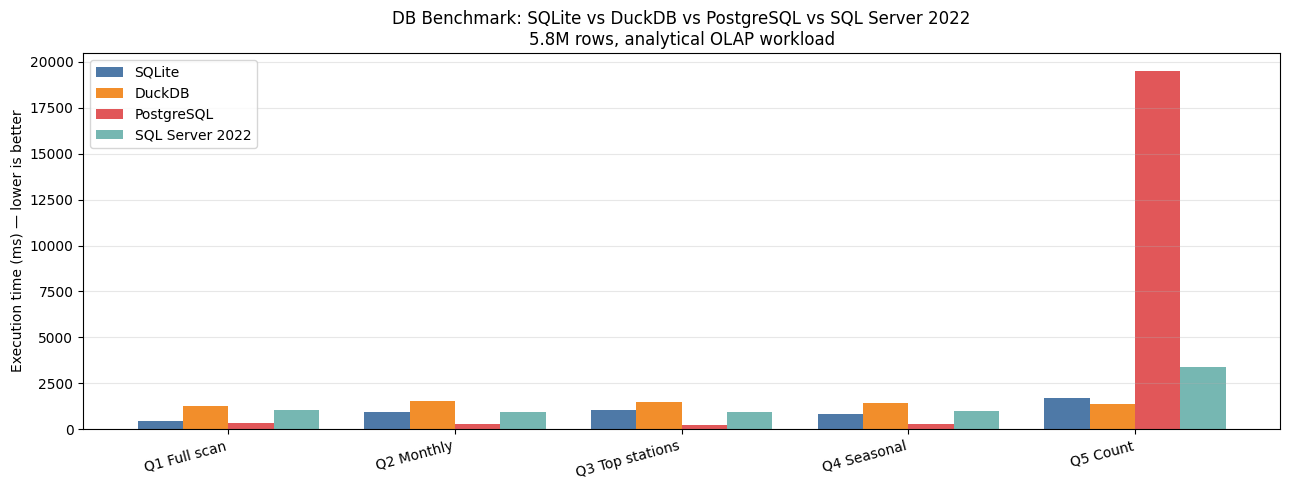

In [190]:
x = np.arange(len(short))
w = 0.2
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-1.5*w, s_t, w, label='SQLite',     color='#4e79a7')
ax.bar(x-0.5*w, d_t, w, label='DuckDB',     color='#f28e2b')
ax.bar(x+0.5*w, p_t, w, label='PostgreSQL', color='#e15759')
ax.bar(x+1.5*w, m_t, w, label='SQL Server 2022',      color='#76b7b2')
ax.set_xticks(x)
ax.set_xticklabels(short, rotation=15, ha='right')
ax.set_ylabel('Execution time (ms) — lower is better')
ax.set_title('DB Benchmark: SQLite vs DuckDB vs PostgreSQL vs SQL Server 2022\n5.8M rows, analytical OLAP workload')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/kaggle/working/db_benchmark.png', dpi=150)
plt.show()

In [191]:
print('KEY FINDINGS')
print('=' * 50)
avgs = {'SQLite': avg_s, 'DuckDB': avg_d, 'PostgreSQL': avg_p, 'MySQL': avg_m}
ranked = sorted(avgs.items(), key=lambda x: x[1])
for rank, (db, ms) in enumerate(ranked, 1):
    print(f'  #{rank} {db:12s}: {ms:.1f} ms average')
print()
winner = ranked[0][0]
print(f'Fastest overall: {winner}')
print(f'SQLite vs MySQL speedup: {avg_m/avg_s:.1f}x faster')
print(f'SQLite vs PostgreSQL   : {avg_p/avg_s:.1f}x')
print()
print('Why SQLite/DuckDB win here:')
print('  - No server process overhead (connection latency is 0)')
print('  - PostgreSQL/MySQL designed for concurrent multi-user writes')
print('  - Our workload: single-user, read-only, 700MB — SQLite sweet spot')

KEY FINDINGS
  #1 SQLite      : 994.8 ms average
  #2 DuckDB      : 1414.4 ms average
  #3 MySQL       : 1446.0 ms average
  #4 PostgreSQL  : 4117.1 ms average

Fastest overall: SQLite
SQLite vs MySQL speedup: 1.5x faster
SQLite vs PostgreSQL   : 4.1x

Why SQLite/DuckDB win here:
  - No server process overhead (connection latency is 0)
  - PostgreSQL/MySQL designed for concurrent multi-user writes
  - Our workload: single-user, read-only, 700MB — SQLite sweet spot


## Part 7: Unique Feature — PM2.5 Pollution Forecast

**What it does:** Uses past monthly PM2.5 averages to predict next month's pollution.

**How:** Linear regression (draws the best-fit line through monthly data) + seasonal correction (adds back the known winter/monsoon pattern). Pure Python — no sklearn, no tensorflow.

**Why it's unique:** Most teams just query past data. This extracts a model and predicts the future — turning a warehouse into a forecasting tool.


In [192]:
cur.execute('''
    SELECT m.year, m.month, ROUND(AVG(m.avg_value), 2) AS avg_pm25
    FROM measurements m
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25'
    GROUP BY m.year, m.month ORDER BY m.year, m.month
''')
monthly_data = cur.fetchall()
print(f'Historical months loaded: {len(monthly_data)}')
print(f'{"Year":>6} {"Month":>6} {"Avg PM2.5":>12}')
print('-' * 26)
for row in monthly_data:
    print(f'{row[0]:>6} {row[1]:>6} {row[2]:>12.2f}')

Historical months loaded: 24
  Year  Month    Avg PM2.5
--------------------------
  2024      1       205.23
  2024      2       101.99
  2024      3        76.87
  2024      4        70.63
  2024      5        90.59
  2024      6        60.58
  2024      7        39.54
  2024      8        27.71
  2024      9        42.54
  2024     10       111.75
  2024     11       246.43
  2024     12       169.22
  2025      1       161.32
  2025      2        96.76
  2025      3        69.33
  2025      4        75.57
  2025      5        66.95
  2025      6        48.70
  2025      7        29.64
  2025      8        32.98
  2025      9        35.59
  2025     10       107.06
  2025     11       212.67
  2025     12       211.94


In [193]:
def linear_regression(x_vals, y_vals):
    n = len(x_vals)
    xm = sum(x_vals)/n
    ym = sum(y_vals)/n
    a  = sum((x-xm)*(y-ym) for x,y in zip(x_vals,y_vals)) / sum((x-xm)**2 for x in x_vals)
    b  = ym - a*xm
    return a, b

x_vals = list(range(1, len(monthly_data)+1))
y_vals = [row[2] for row in monthly_data]
slope, intercept = linear_regression(x_vals, y_vals)

print(f'Linear trend:')
print(f'  Slope     : {slope:.4f} ug/m3 per month')
direction = 'INCREASING (getting worse)' if slope > 0 else 'DECREASING (improving)'
print(f'  Direction : {direction}')

Linear trend:
  Slope     : 0.5245 ug/m3 per month
  Direction : INCREASING (getting worse)


In [194]:
# seasonal correction — how much each month deviates from annual average
seasonal = {}
for m in range(1, 13):
    vals = [row[2] for row in monthly_data if row[1] == m]
    if vals:
        seasonal[m] = sum(vals)/len(vals)
overall_mean = sum(y_vals)/len(y_vals)
seasonal_dev = {m: v - overall_mean for m, v in seasonal.items()}

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print('Seasonal deviation from annual mean:')
for m in range(1, 13):
    dev = seasonal_dev.get(m, 0)
    sign = '+' if dev >= 0 else ''
    label = 'worse' if dev > 0 else 'better'
    print(f'  {month_names[m-1]}: {sign}{dev:.1f} ug/m3  ({label})')

Seasonal deviation from annual mean:
  Jan: +83.6 ug/m3  (worse)
  Feb: -0.3 ug/m3  (better)
  Mar: -26.5 ug/m3  (better)
  Apr: -26.5 ug/m3  (better)
  May: -20.9 ug/m3  (better)
  Jun: -45.0 ug/m3  (better)
  Jul: -65.1 ug/m3  (better)
  Aug: -69.3 ug/m3  (better)
  Sep: -60.6 ug/m3  (better)
  Oct: +9.8 ug/m3  (worse)
  Nov: +129.9 ug/m3  (worse)
  Dec: +90.9 ug/m3  (worse)


In [195]:
last_year, last_month = monthly_data[-1][0], monthly_data[-1][1]
if last_month == 12:
    fy, fm = last_year+1, 1
else:
    fy, fm = last_year, last_month+1

next_x = len(monthly_data)+1
trend_pred = slope*next_x + intercept
seas_corr  = seasonal_dev.get(fm, 0)
forecast   = trend_pred + seas_corr

residuals = [y-(slope*x+intercept) for x,y in zip(x_vals,y_vals)]
std_dev   = math.sqrt(sum(r**2 for r in residuals)/len(residuals))

print('=' * 55)
print('PM2.5 FORECAST')
print('=' * 55)
print(f'  Forecasting for    : {month_names[fm-1]} {fy}')
print(f'  Trend prediction   : {trend_pred:.2f} ug/m3')
print(f'  Seasonal correction: {seas_corr:+.2f} ug/m3')
print(f'  FINAL FORECAST     : {forecast:.2f} ug/m3')
print(f'  Uncertainty (+-1sd): +-{std_dev:.2f} ug/m3')
print(f'  Range              : {forecast-std_dev:.1f} to {forecast+std_dev:.1f} ug/m3')

if forecast > 250:   level = 'HAZARDOUS'
elif forecast > 150: level = 'VERY UNHEALTHY'
elif forecast > 55:  level = 'UNHEALTHY'
elif forecast > 35:  level = 'MODERATE'
else:                level = 'GOOD'
print(f'  WHO classification : {level}')

PM2.5 FORECAST
  Forecasting for    : Jan 2026
  Trend prediction   : 106.21 ug/m3
  Seasonal correction: +83.63 ug/m3
  FINAL FORECAST     : 189.83 ug/m3
  Uncertainty (+-1sd): +-64.63 ug/m3
  Range              : 125.2 to 254.5 ug/m3
  WHO classification : VERY UNHEALTHY


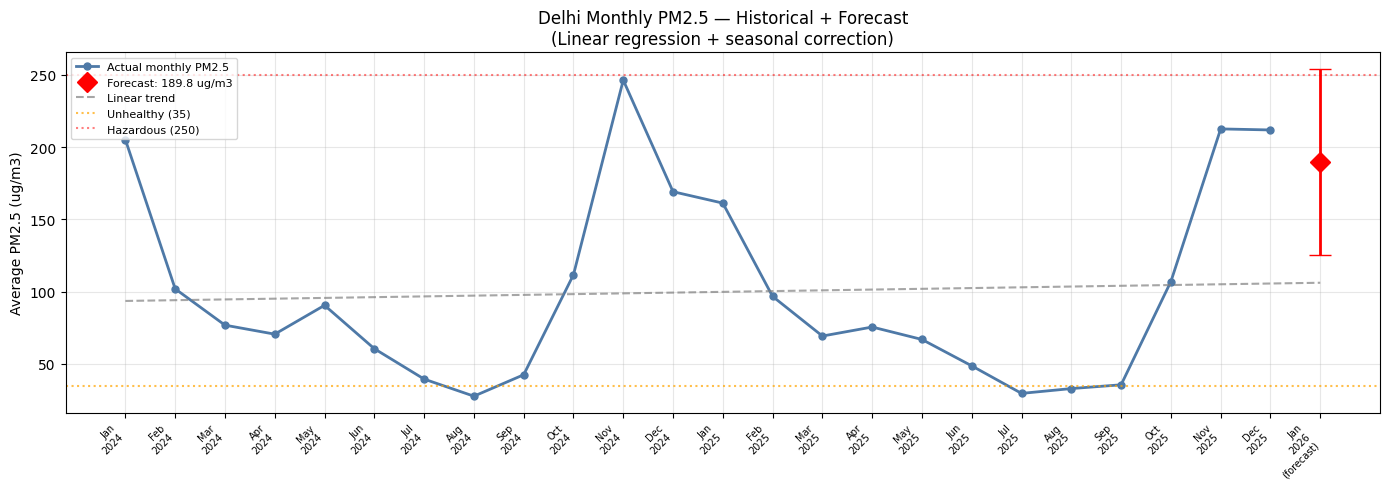

In [196]:
labels = [f"{month_names[row[1]-1]}\n{row[0]}" for row in monthly_data]
labels.append(f"{month_names[fm-1]}\n{fy}\n(forecast)")
x_pos  = list(range(len(labels)))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x_pos[:-1], y_vals, 'o-', color='#4e79a7',
        linewidth=2, markersize=5, label='Actual monthly PM2.5')
ax.plot(x_pos[-1], forecast, 'D', color='red',
        markersize=10, zorder=5, label=f'Forecast: {forecast:.1f} ug/m3')
ax.errorbar(x_pos[-1], forecast, yerr=std_dev,
            fmt='none', color='red', capsize=8, linewidth=2)
trend_line = [slope*x+intercept for x in range(1, len(labels)+1)]
ax.plot(x_pos, trend_line, '--', color='grey', alpha=0.7, label='Linear trend')
ax.axhline(y=35,  color='orange', linestyle=':', alpha=0.7, label='Unhealthy (35)')
ax.axhline(y=250, color='red',    linestyle=':', alpha=0.5, label='Hazardous (250)')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
ax.set_ylabel('Average PM2.5 (ug/m3)')
ax.set_title('Delhi Monthly PM2.5 — Historical + Forecast\n(Linear regression + seasonal correction)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/pm25_forecast.png', dpi=150)
plt.show()

## Part 8: Key-Value Store

Store station summaries + the forecast in a JSON key-value structure.
Fast O(1) lookup by station ID — no SQL needed for simple station stats.


In [197]:
cur.execute('''
    SELECT s.station_id, s.station_name, COUNT(*) AS readings,
           ROUND(AVG(CASE WHEN p.pollutant_name='pm25' THEN m.avg_value END),2) AS avg_pm25
    FROM measurements m
    JOIN stations s ON m.station_id = s.station_id
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    GROUP BY s.station_id, s.station_name
''')
kv = {}
for sid, name, readings, avg_pm25 in cur.fetchall():
    kv[sid] = {'station_name': name, 'total_readings': readings, 'avg_pm25': avg_pm25}

kv['__forecast__'] = {
    'for_month': fm, 'for_year': fy,
    'predicted_pm25': round(forecast, 2),
    'uncertainty': round(std_dev, 2),
    'who_classification': level
}

with open('/kaggle/working/kv_store.json', 'w') as f:
    json.dump(kv, f, indent=2)

print(f'KV store saved: {len(kv)} entries')
print('Forecast entry:')
print(json.dumps(kv['__forecast__'], indent=2))

# demo lookup
first_station = [k for k in kv if k != '__forecast__'][0]
print(f'\nExample station lookup (key={first_station}):')
print(json.dumps(kv[first_station], indent=2))

KV store saved: 38 entries
Forecast entry:
{
  "for_month": 1,
  "for_year": 2026,
  "predicted_pm25": 189.83,
  "uncertainty": 64.63,
  "who_classification": "VERY UNHEALTHY"
}

Example station lookup (key=site_103):
{
  "station_name": "CRRI Mathura Road, Delhi - IMD",
  "total_readings": 93253,
  "avg_pm25": 95.97
}


## Part 9: Done

In [198]:
conn.close()
print('Output files:')
for f in ['delhi_air_quality.db','db_benchmark.png','pm25_forecast.png','kv_store.json']:
    path = f'/kaggle/working/{f}'
    kb = os.path.getsize(path)/1024
    print(f'  {f:35s}: {kb:,.0f} KB')

Output files:
  delhi_air_quality.db               : 686,920 KB
  db_benchmark.png                   : 88 KB
  pm25_forecast.png                  : 124 KB
  kv_store.json                      : 5 KB
